# MAE vs train size

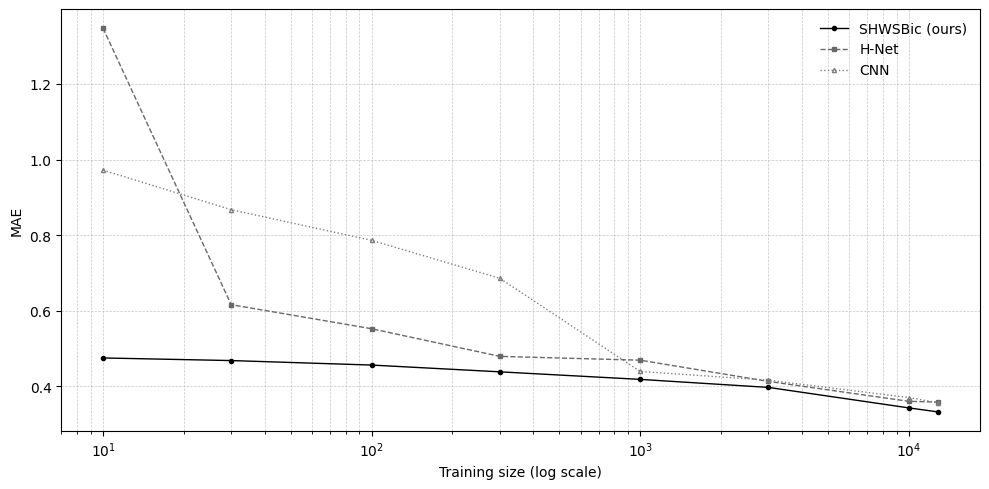

In [1]:
import numpy as np
import matplotlib.pyplot as plt

train_size = np.array([10, 30, 100, 300, 1000, 3000, 10000, 12868])
shwsbic_knn = np.array([0.4750, 0.4681, 0.4562, 0.4383, 0.4183, 0.3971, 0.3429, 0.3322])
h_net = np.array([1.3474, 0.6160, 0.5523, 0.4792, 0.4691, 0.4130, 0.3603, 0.3581])
cnn = np.array([0.9718, 0.8672, 0.7861, 0.6858, 0.4393, 0.4161, 0.3703, 0.3564])

fig, ax = plt.subplots(figsize=(10, 5))

lw = 1
ms = 3

ax.plot(train_size, shwsbic_knn, marker='o', linestyle='-', color="black",
        label="SHWSBic (ours)", ms=ms, lw=lw, fillstyle='full')
ax.plot(train_size, h_net, marker='s', linestyle='--', color="dimgray",
        label="H-Net", ms=ms, lw=lw, fillstyle='full')
ax.plot(train_size, cnn, marker='^', linestyle=':', color="gray",
        label="CNN", ms=ms, lw=lw, fillstyle='none')

ax.set_xscale('log')
ax.set_xlabel("Training size (log scale)")
ax.set_ylabel("MAE")
ax.grid(True, which="both", ls="--", lw=0.5, alpha=0.7)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()


# Exposure (SNR) vs MAE

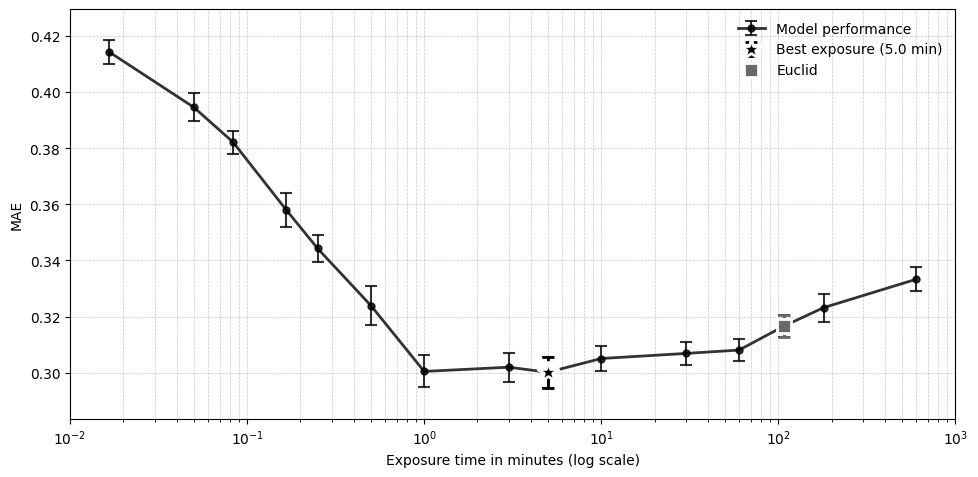

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Dataset 1 (given in seconds -> convert to minutes)
data1 = {
    "exposure": [1, 3, 5, 10, 15, 30],  # seconds
    "mae": [0.414203, 0.394539, 0.382117, 0.357935, 0.344304, 0.323956],
    "mae_std": [0.004145, 0.004996, 0.004105, 0.006104, 0.004896, 0.006791],
    "rmse": [0.506730, 0.489923, 0.485287, 0.479263, 0.481252, 0.463818],
    "rmse_std": [0.004552, 0.005396, 0.004625, 0.010361, 0.005763, 0.008512],
}
# convert seconds → minutes
data1["exposure"] = [x / 60 for x in data1["exposure"]]

# Dataset 2 (already in minutes)
data2 = {
    "exposure": [1, 3, 5, 10, 30, 60, 108, 180, 600],  # minutes
    "mae": [0.3005, 0.3020, 0.3002, 0.3051, 0.3069, 0.3081, 0.3167, 0.3232, 0.3333],
    "mae_std": [0.0057, 0.0052, 0.0055, 0.0045, 0.0041, 0.0038, 0.0038, 0.0050, 0.0042],
    "rmse": [0.4224, 0.4238, 0.4219, 0.4271, 0.4295, 0.4289, 0.4362, 0.4428, 0.4493],
    "rmse_std": [0.0061, 0.0062, 0.0067, 0.0062, 0.0063, 0.0055, 0.0059, 0.0069, 0.0052],
}

# Convert to DataFrames
df1 = pd.DataFrame(data1)
df2 = pd.DataFrame(data2)

# Combine datasets - prioritize df2 (minutes data) over df1 (converted seconds) for overlaps
df_combined = pd.concat([df2, df1]).drop_duplicates(subset="exposure", keep="first")
df_combined = df_combined.sort_values("exposure").reset_index(drop=True)

# Set up matplotlib for publication-quality output
# plt.rcParams.update({
#     "text.usetex": False,
#     "font.family": "serif",
#     "font.size": 14,
#     "axes.labelsize": 16,
#     "axes.titlesize": 16,
#     "legend.fontsize": 12,
#     "xtick.labelsize": 12,
#     "ytick.labelsize": 12,
#     "figure.dpi": 300
# })

# Create the plot
fig, ax = plt.subplots(figsize=(10, 5))

# Main performance curve - grayscale with distinctive style
ax.errorbar(
    df_combined["exposure"], df_combined["mae"],
    yerr=df_combined["mae_std"],
    fmt='o-', capsize=4, capthick=1.5, elinewidth=1.5,
    color="black", markersize=5, linewidth=2,
    label="Model performance", alpha=0.8, fillstyle='full'
)

# Find and highlight optimal point (minimum MAE)
optimal_idx = df_combined['mae'].idxmin()
optimal_point = df_combined.loc[optimal_idx]

ax.errorbar(
    optimal_point["exposure"], optimal_point["mae"],
    yerr=optimal_point["mae_std"],
    fmt='*', color="black", markersize=16,
    capsize=4, capthick=2, elinewidth=2,
    label=f"Best exposure ({optimal_point['exposure']:.1f} min)",
    markeredgecolor='white', markeredgewidth=2, zorder=10
)

# Highlight Euclid point (108 minutes)
euclid_point = df_combined[df_combined["exposure"] == 108]
if not euclid_point.empty:
    ax.errorbar(
        euclid_point["exposure"], euclid_point["mae"],
        yerr=euclid_point["mae_std"],
        fmt='s', color="dimgray", markersize=10,
        capsize=4, capthick=2, elinewidth=2,
        label="Euclid",
        markeredgecolor='white', markeredgewidth=2, zorder=10,
        fillstyle='full'
    )

# Format the plot
ax.set_xscale("log")
ax.set_xlabel("Exposure time in minutes (log scale)")
ax.set_ylabel("MAE")
# ax.set_title("Model Performance vs Exposure Time")

# Professional grid
ax.grid(True, which="both", ls="--", lw=0.5, alpha=0.7)

# Clean legend without frame
ax.legend(frameon=False)

# Set reasonable axis limits
ax.set_xlim(0.01, 1000)

# Add some padding to y-axis
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min - 0.005, y_max + 0.005)

plt.rcParams.update({
    "text.usetex": False,  # keep it safe for environments without LaTeX
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 300
})
plt.tight_layout()
plt.show()